# Explainable Pneumonia Detection from Chest X-Rays

## Model Training

This notebook focuses on training a deep learning model for pneumonia classification using transfer learning.

The workflow includes:

- Loading the processed dataset splits
- Creating PyTorch datasets and dataloaders
- Handling class imbalance
- Fine-tuning a pretrained ResNet18 model
- Training and validating the model
- Saving the best-performing model
- Evaluating performance on the unseen test set

In [1]:
# Import Libraries

import os
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.utils.class_weight import compute_class_weight

In [2]:
print("PyTorch Version:", torch.__version__)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch Version: 2.11.0+cu128
Device: cuda
GPU: Tesla T4


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
# ==========================================
# Project Paths

PROJECT_DIR = Path("/content/drive/MyDrive/pneumonia_project")

SPLIT_DIR = PROJECT_DIR / "data_splits"

TRAIN_CSV = SPLIT_DIR / "train_split.csv"
VAL_CSV = SPLIT_DIR / "val_split.csv"
TEST_CSV = SPLIT_DIR / "test_split.csv"

MODEL_DIR = PROJECT_DIR / "models"
OUTPUT_DIR = PROJECT_DIR / "outputs"

In [11]:
train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)
test_df = pd.read_csv(TEST_CSV)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (4447, 3)
Validation: (785, 3)
Test: (624, 3)


## Image Configuration

The images are resized to **224 × 224** pixels to match the input size expected by pretrained CNN architectures such as ResNet18.

ImageNet normalization statistics are used because the pretrained model was originally trained on the ImageNet dataset.

In [12]:
# ==========================================
# Image Configuration

IMG_SIZE = 224

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

In [13]:
from torchvision import transforms
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05)
    ),
    transforms.ColorJitter(
        brightness=0.10,
        contrast=0.10
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

In [14]:
from torch.utils.data import Dataset
from PIL import Image

class ChestXRayDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

        self.label_map = {
            "NORMAL": 0,
            "PNEUMONIA": 1
        }

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):

        row = self.dataframe.iloc[idx]

        image = Image.open(row["image_path"]).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = self.label_map[row["label"]]

        return image, label

In [15]:
train_dataset = ChestXRayDataset(
    train_df,
    transform=train_transform
)

val_dataset = ChestXRayDataset(
    val_df,
    transform=val_test_transform
)

test_dataset = ChestXRayDataset(
    test_df,
    transform=val_test_transform
)

In [16]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [17]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


## Handling Class Imbalance

The training dataset contains significantly more pneumonia images than normal images.

To reduce bias toward the majority class, class weights are computed from the training data and incorporated into the loss function.

Using weighted loss allows the model to penalize mistakes on the minority class more heavily without modifying the dataset itself.

In [18]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Convert labels to integers
train_labels = train_df["label"].map({
    "NORMAL": 0,
    "PNEUMONIA": 1
}).values

# Compute balanced class weights
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

print("Class Weights:", class_weights)

Class Weights: [1.93853531 0.67378788]


In [19]:
class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)

print(class_weights)

tensor([1.9385, 0.6738], device='cuda:0')


## Transfer Learning with ResNet18

Instead of training a convolutional neural network from scratch, a pretrained ResNet18 model is used.

The model was originally trained on the ImageNet dataset, allowing it to leverage previously learned visual features such as edges, textures, and shapes.

Transfer learning improves convergence, reduces training time, and typically achieves better performance on relatively small medical imaging datasets.

In [20]:
from torchvision.models import resnet18, ResNet18_Weights

# Load pretrained ResNet18
weights = ResNet18_Weights.DEFAULT

model = resnet18(weights=weights)

print(model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 168MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [21]:
print(model.fc)

Linear(in_features=512, out_features=1000, bias=True)


### Replacing the Classification Layer

The original ResNet18 model contains a fully connected layer with 1,000 output neurons corresponding to the ImageNet dataset.

Since this project performs binary classification (Normal vs. Pneumonia), the final classification layer is replaced with a new fully connected layer having two output neurons.

In [22]:
import torch.nn as nn

# Number of input features to the classifier
num_features = model.fc.in_features

# Replace the final layer
model.fc = nn.Linear(
    in_features=num_features,
    out_features=2
)

print(model.fc)

Linear(in_features=512, out_features=2, bias=True)


### Freezing the Feature Extractor

The pretrained convolutional layers are frozen so that their learned feature representations remain unchanged during the initial training phase.

Only the newly added classification layer is trained, allowing the model to adapt efficiently to the pneumonia classification task while reducing training time and the risk of overfitting.

In [23]:
# Freeze all pretrained layers
for param in model.parameters():
    param.requires_grad = False

# Keep only the new classifier trainable
for param in model.fc.parameters():
    param.requires_grad = True

In [24]:
print("Trainable Parameters:\n")

for name, param in model.named_parameters():
    if param.requires_grad:
        print(name)

Trainable Parameters:

fc.weight
fc.bias


In [25]:
model = model.to(device)

print(f"Model is running on: {device}")

Model is running on: cuda


## Loss Function

Cross-Entropy Loss is used for binary classification.

To compensate for the class imbalance, the previously computed class weights are incorporated into the loss function. This increases the penalty for misclassifying images from the minority class, helping the model learn a more balanced decision boundary.

In [26]:
criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

print(criterion)

CrossEntropyLoss()


## Optimizer

The Adam optimizer is used to update the trainable parameters of the classification layer.

Since only the final fully connected layer is being trained during the initial phase, the optimizer updates only those parameters while keeping the pretrained convolutional layers fixed.

In [27]:
optimizer = optim.Adam(
    model.fc.parameters(),
    lr=0.001
)

print(optimizer)

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


## Learning Rate Scheduler

A ReduceLROnPlateau scheduler is employed to automatically decrease the learning rate when the validation loss stops improving. This helps the optimizer converge more effectively and can improve the final model performance.

In [28]:
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.1,
    patience=2
)

print(scheduler)

## Training Function

A dedicated training function is implemented to process one epoch of training.

For each batch, the model performs a forward pass, computes the loss, backpropagates the gradients, updates the trainable parameters, and records both loss and classification accuracy.

In [29]:
from tqdm import tqdm

def train_one_epoch(model, dataloader, criterion, optimizer, device):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(dataloader):

        images = images.to(device)
        labels = labels.to(device)

        # Reset gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Compute loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Statistics
        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        correct += (predicted == labels).sum().item()

        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

## Validation Function

A separate validation function is used to evaluate the model after each training epoch.

Unlike the training phase, no gradient computation or parameter updates are performed. The model is switched to evaluation mode to ensure consistent behavior of layers such as Batch Normalization.

The validation loss and accuracy are monitored throughout training to assess the model's generalization performance and to identify the best-performing model.

In [30]:
def validate_one_epoch(model, dataloader, criterion, device):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in tqdm(dataloader):

            images = images.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(images)

            # Compute loss
            loss = criterion(outputs, labels)

            # Statistics
            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            correct += (predicted == labels).sum().item()

            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

## Training Configuration

The training configuration defines the number of training epochs and initializes variables to monitor model performance.

Separate lists are maintained to store training and validation loss and accuracy for each epoch. The best validation loss is tracked so that the best-performing model can be saved during training.

In [31]:
# ==========================================
# Training Configuration
# ==========================================

NUM_EPOCHS = 10

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

best_val_loss = float("inf")

## Model Training

The model is trained for multiple epochs.

For each epoch:

- One complete pass is performed over the training dataset.
- The model is evaluated on the validation dataset.
- The learning rate scheduler monitors the validation loss.
- The model with the lowest validation loss is saved for later evaluation.

In [32]:
# ==========================================
# Model Training
# ==========================================

for epoch in range(NUM_EPOCHS):

    print(f"\nEpoch [{epoch+1}/{NUM_EPOCHS}]")
    print("-" * 50)

    # Training
    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    # Validation
    val_loss, val_acc = validate_one_epoch(
        model,
        val_loader,
        criterion,
        device
    )

    # Learning rate scheduler
    scheduler.step(val_loss)

    # Store metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    # Print metrics
    print(f"Train Loss : {train_loss:.4f}")
    print(f"Train Acc  : {train_acc:.4f}")

    print(f"Val Loss   : {val_loss:.4f}")
    print(f"Val Acc    : {val_acc:.4f}")

    # Save best model
    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            PROJECT_DIR / "models" / "best_model.pth"
        )

        print("✅ Best model saved!")


Epoch [1/10]
--------------------------------------------------


100%|██████████| 25/25 [02:25<00:00,  5.81s/it]


Train Loss : 0.3513
Train Acc  : 0.8586
Val Loss   : 0.2467
Val Acc    : 0.8764
✅ Best model saved!

Epoch [2/10]
--------------------------------------------------


100%|██████████| 25/25 [00:14<00:00,  1.74it/s]


Train Loss : 0.2350
Train Acc  : 0.9083
Val Loss   : 0.2034
Val Acc    : 0.9006
✅ Best model saved!

Epoch [3/10]
--------------------------------------------------


...

Train Loss : 0.1631
Train Acc  : 0.9352
Val Loss   : 0.1698
Val Acc    : 0.9223

Epoch [9/10]
--------------------------------------------------


100%|██████████| 25/25 [00:14<00:00,  1.74it/s]


Train Loss : 0.1620
Train Acc  : 0.9472
Val Loss   : 0.1406
Val Acc    : 0.9363
✅ Best model saved!

Epoch [10/10]
--------------------------------------------------


100%|██████████| 25/25 [00:14<00:00,  1.72it/s]

Train Loss : 0.1647
Train Acc  : 0.9368
Val Loss   : 0.1457
Val Acc    : 0.9325


Model Evaluation on Test Set

The best-performing model obtained during training is evaluated on the untouched test dataset.

Unlike the training and validation datasets, the test set has not been used for model optimization or hyperparameter tuning. Therefore, the evaluation on this dataset provides an unbiased estimate of the model's real-world performance.

To comprehensively assess the classifier, multiple evaluation metrics are computed, including accuracy, precision, recall, F1-score, and the confusion matrix.

In [34]:
# ==========================================
# Load Best Model
# ==========================================

BEST_MODEL_PATH = MODEL_DIR / "best_model.pth"

model.load_state_dict(torch.load(BEST_MODEL_PATH))

model.eval()

print("Best model loaded successfully!")

Best model loaded successfully!


In [35]:
# ==========================================
# Test Prediction
# ==========================================

all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predictions = torch.max(outputs, 1)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("Total Test Samples:", len(all_labels))

Total Test Samples: 624


Classification Metrics

To evaluate the classifier, four standard performance metrics are computed:

Accuracy measures the overall proportion of correctly classified images.
Precision indicates how many images predicted as pneumonia are actually pneumonia.
Recall (Sensitivity) measures the model's ability to correctly identify pneumonia cases, which is particularly important in medical diagnosis.
F1-score provides a balanced measure by combining precision and recall into a single metric.

These metrics provide a more comprehensive assessment than accuracy alone, especially for datasets with class imbalance.


In [36]:
# ==========================================
# Classification Metrics
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(all_labels, all_predictions)

precision = precision_score(
    all_labels,
    all_predictions
)

recall = recall_score(
    all_labels,
    all_predictions
)

f1 = f1_score(
    all_labels,
    all_predictions
)

print("=" * 40)
print("TEST PERFORMANCE")
print("=" * 40)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

TEST PERFORMANCE
Accuracy : 0.9022
Precision: 0.8871
Recall   : 0.9667
F1 Score : 0.9252


Test Performance Analysis

The trained ResNet18 model achieved strong performance on the unseen test dataset, demonstrating good generalization capability.

The model obtained an overall accuracy of 90.22%, indicating that it correctly classified the majority of chest X-ray images.

A particularly notable result is the 96.67% recall for the pneumonia class, showing that the model successfully detected nearly all pneumonia cases. In medical imaging applications, maintaining a high recall is essential because missing an actual pneumonia case can have serious clinical consequences.

Although the precision is slightly lower (88.71%), indicating the presence of some false-positive predictions, the resulting F1-score of 92.52% reflects a strong balance between precision and recall.

Overall, the evaluation demonstrates that the model generalizes well to previously unseen chest X-ray images while maintaining excellent sensitivity for pneumonia detection.

In [37]:
# ==========================================
# Confusion Matrix
# ==========================================

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    all_labels,
    all_predictions
)

print(cm)

[[186  48]
 [ 13 377]]


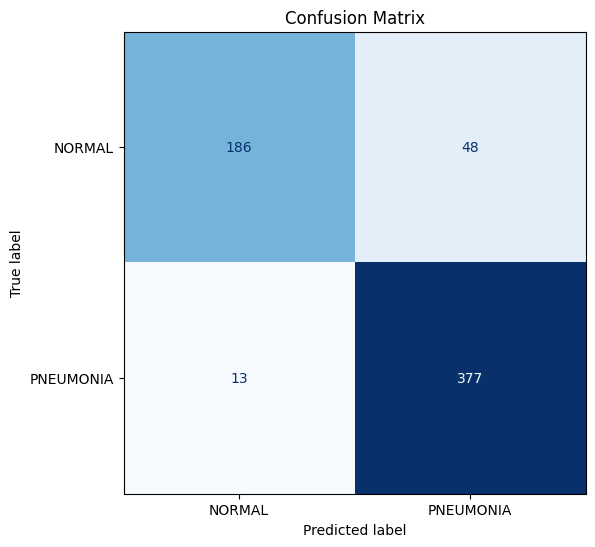

In [38]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["NORMAL", "PNEUMONIA"]
)

fig, ax = plt.subplots(figsize=(6, 6))

disp.plot(
    cmap="Blues",
    values_format="d",
    ax=ax,
    colorbar=False
)

plt.title("Confusion Matrix")
plt.show()

## Confusion Matrix Analysis

The confusion matrix summarizes the classification performance of the trained ResNet18 model on the unseen test dataset.

The model correctly classified **186 Normal** chest X-rays and **377 Pneumonia** chest X-rays. Only **13 pneumonia cases** were incorrectly predicted as normal, resulting in a high recall of **96.67%**, which is particularly important in medical diagnosis because missed pneumonia cases may delay treatment.

The model incorrectly classified **48 normal chest X-rays** as pneumonia. Although this slightly reduces precision, false-positive predictions are generally less critical than false negatives in a screening application.

Overall, the confusion matrix demonstrates that the model is highly effective at identifying pneumonia while maintaining strong overall classification performance.

## Classification Report

The classification report provides class-wise evaluation metrics, including precision, recall, F1-score, and support for each class.

Unlike overall accuracy, these metrics evaluate how well the model performs on each individual class. This is particularly important for imbalanced medical datasets, where relying solely on accuracy may not accurately reflect the model's diagnostic performance.

In [39]:
# ==========================================
# Classification Report
# ==========================================

from sklearn.metrics import classification_report

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=["NORMAL", "PNEUMONIA"]
    )
)

              precision    recall  f1-score   support

      NORMAL       0.93      0.79      0.86       234
   PNEUMONIA       0.89      0.97      0.93       390

    accuracy                           0.90       624
   macro avg       0.91      0.88      0.89       624
weighted avg       0.90      0.90      0.90       624



## Classification Report Analysis

The classification report provides a detailed evaluation of the model's performance for each class.

For the **Normal** class, the model achieved a precision of **93%** and a recall of **79%**. This indicates that while most images predicted as normal were correctly classified, some normal chest X-rays were identified as pneumonia.

For the **Pneumonia** class, the model achieved a precision of **89%** and an excellent recall of **97%**, demonstrating its ability to detect the vast majority of pneumonia cases. This high recall is particularly desirable in medical diagnosis because it minimizes the number of missed pneumonia patients.

Overall, the model achieved an accuracy of **90.22%** with a weighted F1-score of approximately **90%**, indicating strong generalization performance on previously unseen chest X-ray images.

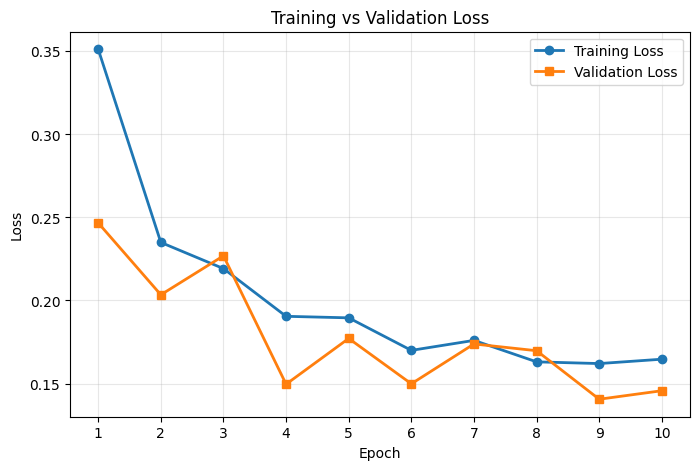

In [41]:
# ==========================================
# Training & Validation Loss
# ==========================================

import matplotlib.pyplot as plt

epochs = range(1, NUM_EPOCHS + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    train_losses,
    marker="o",
    linewidth=2,
    label="Training Loss"
)

plt.plot(
    epochs,
    val_losses,
    marker="s",
    linewidth=2,
    label="Validation Loss"
)

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.grid(alpha=0.3)
plt.legend()

plt.show()

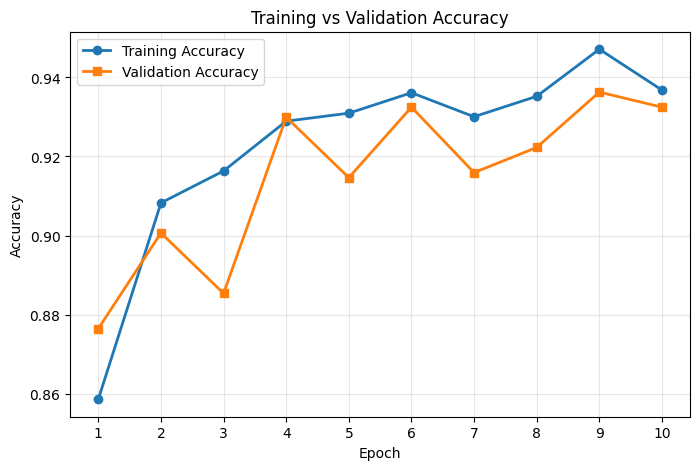

In [42]:
# ==========================================
# Training & Validation Accuracy
# ==========================================

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    train_accuracies,
    marker="o",
    linewidth=2,
    label="Training Accuracy"
)

plt.plot(
    epochs,
    val_accuracies,
    marker="s",
    linewidth=2,
    label="Validation Accuracy"
)

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(epochs)
plt.grid(alpha=0.3)
plt.legend()

plt.show()

## Training Curve Analysis

The training curves indicate that the model converged successfully during the training process.

Both the training and validation losses decreased steadily over successive epochs, demonstrating effective optimization. Similarly, the training and validation accuracies increased consistently, indicating improved predictive performance.

Although minor fluctuations were observed in the validation metrics, the overall trends remained stable, suggesting that the model generalized well without significant overfitting.

The best validation performance was achieved during **Epoch 9**, after which the validation metrics remained relatively stable, indicating that the model had effectively converged.

In [43]:
# ==========================================
# Save Training History
# ==========================================

history_df = pd.DataFrame({
    "epoch": range(1, NUM_EPOCHS + 1),
    "train_loss": train_losses,
    "val_loss": val_losses,
    "train_accuracy": train_accuracies,
    "val_accuracy": val_accuracies
})

history_path = OUTPUT_DIR / "training_history.csv"

history_df.to_csv(history_path, index=False)

print("Training history saved to:")
print(history_path)

Training history saved to:
/content/drive/MyDrive/pneumonia_project/outputs/training_history.csv


In [44]:
# ==========================================
# Save Final Model
# ==========================================

FINAL_MODEL_PATH = MODEL_DIR / "final_model.pth"

torch.save(
    model.state_dict(),
    FINAL_MODEL_PATH
)

print("Final model saved to:")
print(FINAL_MODEL_PATH)

Final model saved to:
/content/drive/MyDrive/pneumonia_project/models/final_model.pth


## Conclusion

A transfer learning approach based on a pretrained ResNet18 architecture was successfully trained to classify chest X-ray images into Normal and Pneumonia categories.

The model demonstrated strong performance on the unseen test dataset, achieving over **90% classification accuracy** while maintaining a **96.67% recall** for pneumonia detection. The confusion matrix and classification report further confirmed the model's ability to correctly identify the majority of pneumonia cases with relatively few false negatives.

The trained model has been saved and will be used in the subsequent notebook to generate Grad-CAM visualizations, providing interpretable explanations for the model's predictions.